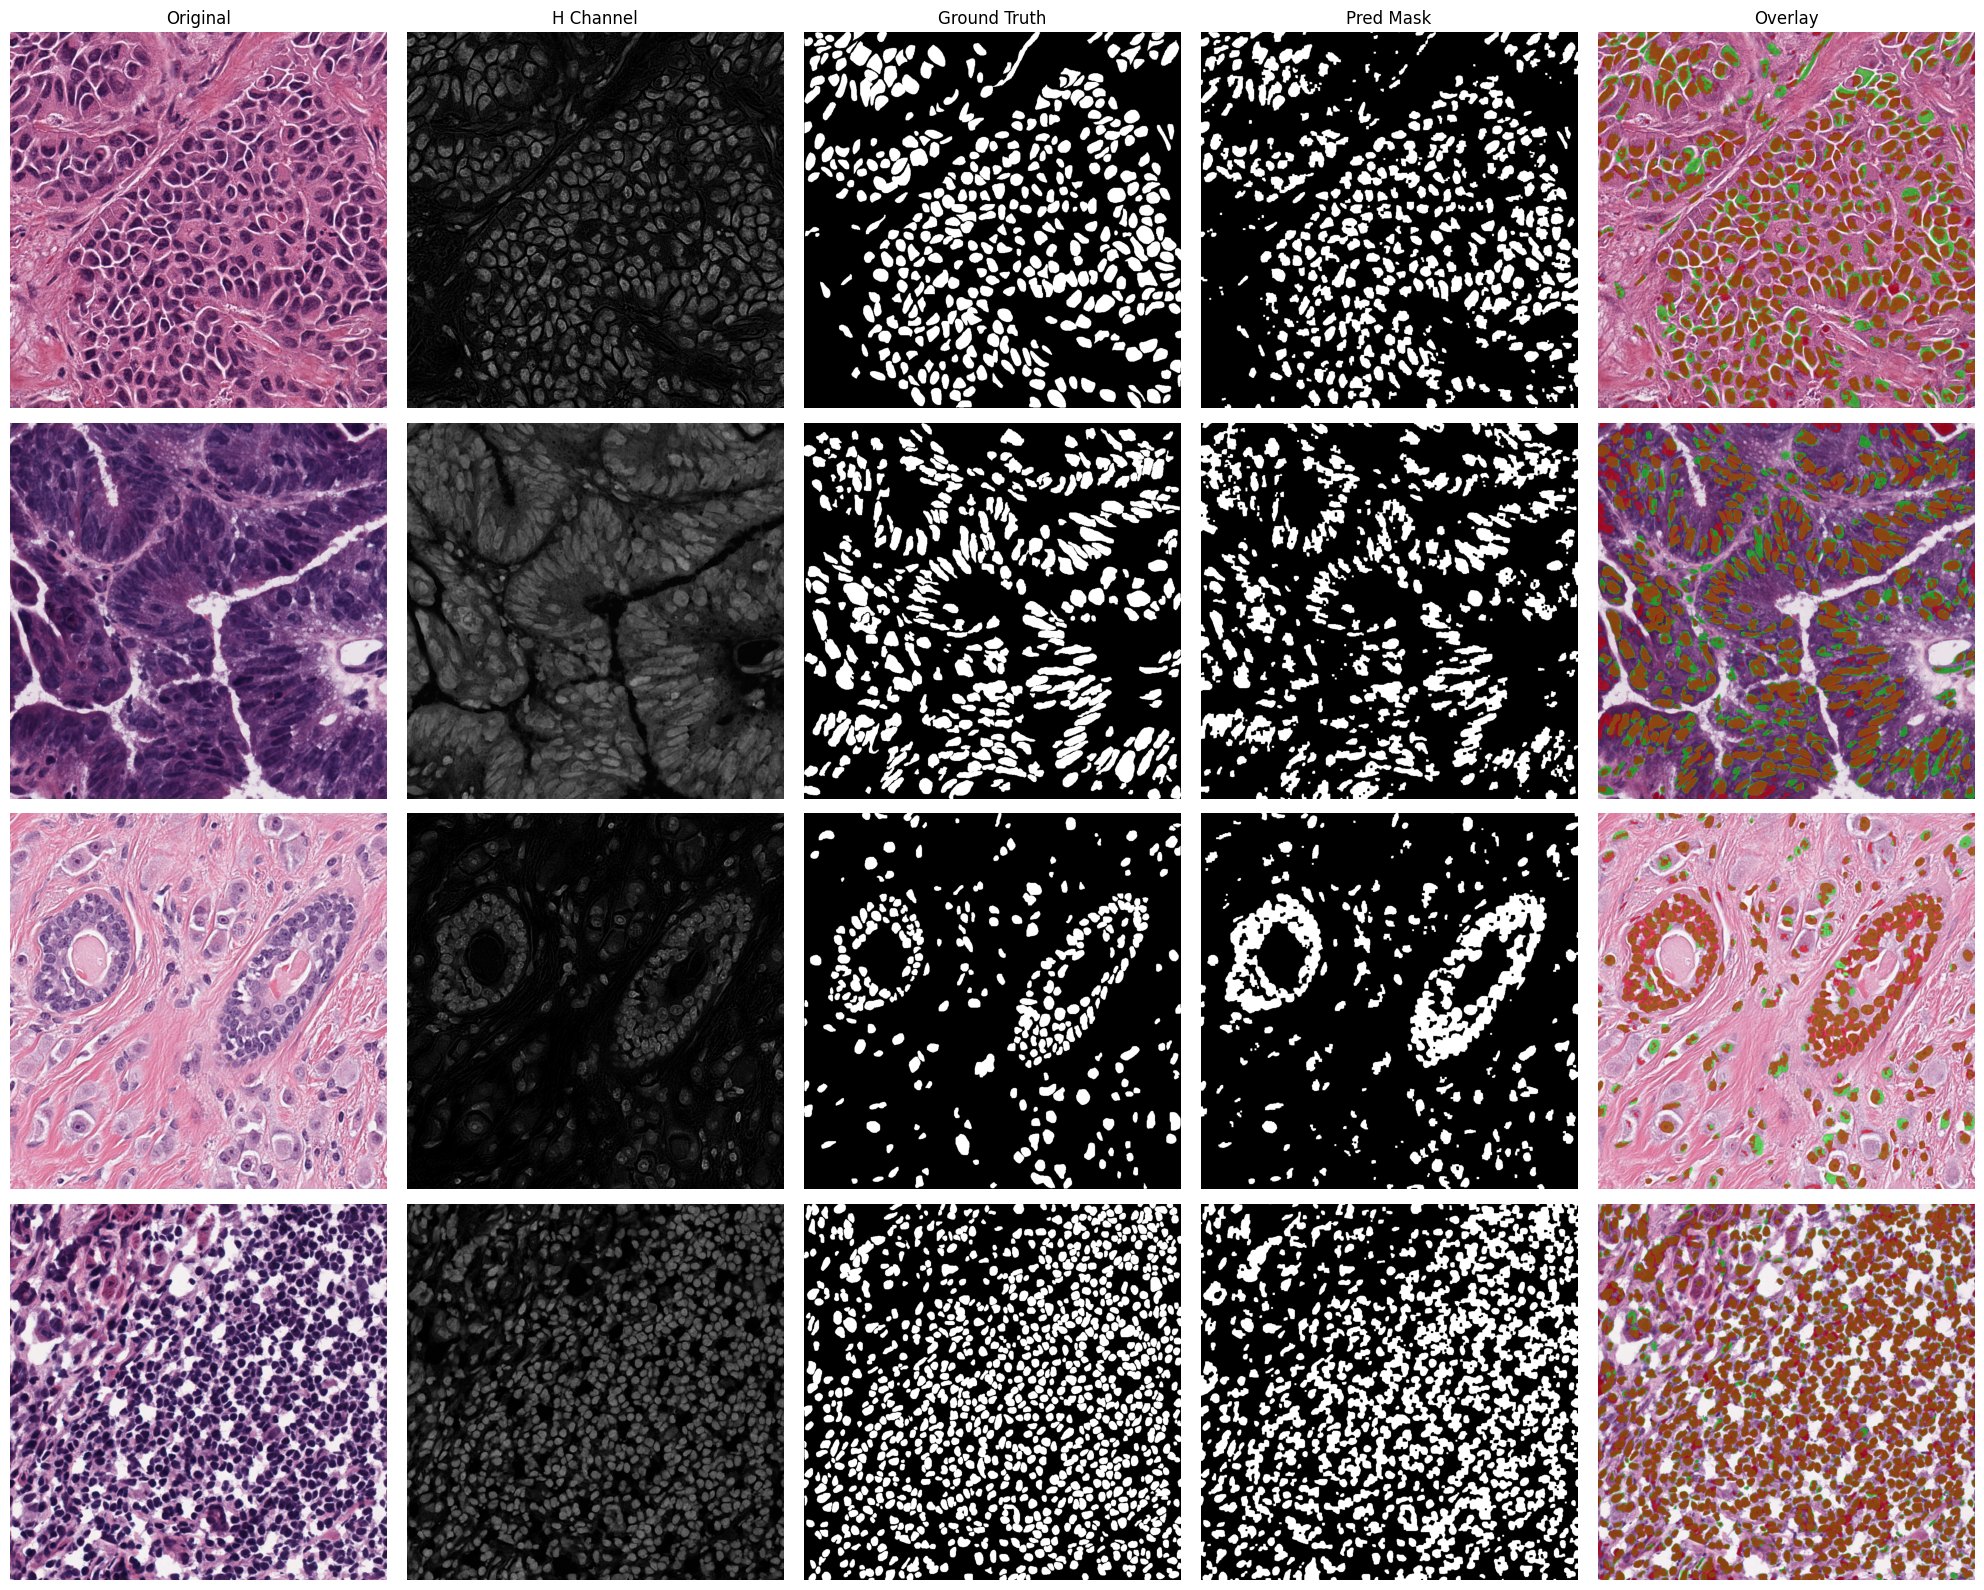


File              IoU     Dice   Time (s)
------------------------------------------
AR             0.6543   0.7910     0.0852
AY             0.5965   0.7473     0.0913
E2             0.6066   0.7551     0.0777
RD             0.7671   0.8682     0.0722
------------------------------------------
Average        0.6561   0.7904     0.0816


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import os
import time
from skimage.color import rgb2hed

# ── CONFIG ───────────────────────────────────────────────────────────────
folder_img = r"C:\Users\Sem 6\Pengolahan Citra Medika\5023231017_Jeremia Christ Immanuel Manalu_Final Project_Nucleus Cell Detection and Segmentation_PCM\MoNuSeg2018\Tissue Images"
folder_xml = r"C:\Users\Sem 6\Pengolahan Citra Medika\5023231017_Jeremia Christ Immanuel Manalu_Final Project_Nucleus Cell Detection and Segmentation_PCM\MoNuSeg2018\Annotations"

filenames = [
    "TCGA-AR-A1AS-01Z-00-DX1",
    "TCGA-AY-A8YK-01A-01-TS1",
    "TCGA-E2-A1B5-01Z-00-DX1",
    "TCGA-RD-A8N9-01A-01-TS1",
]

THRESHOLD_MAP = {
    "TCGA-AR-A1AS-01Z-00-DX1": "otsu",
    "TCGA-AY-A8YK-01A-01-TS1": "percentile",
    "TCGA-E2-A1B5-01Z-00-DX1": "otsu",
    "TCGA-RD-A8N9-01A-01-TS1": "otsu",
}

def xml_to_mask(xml_path, img_shape):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    mask = np.zeros(img_shape[:2], dtype=np.uint8)
    for region in root.findall(".//Region"):
        vertices = region.findall(".//Vertex")
        pts = np.array(
            [[float(v.attrib["X"]), float(v.attrib["Y"])] for v in vertices],
            dtype=np.int32
        )
        cv2.fillPoly(mask, [pts], 255)
    return mask

def segment_color_deconv_v3(img_bgr, fname):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # 1. Color deconvolution → H channel
    img_hed = rgb2hed(img_rgb.astype(np.float32) / 255.0)
    h_channel = img_hed[:, :, 0]
    h_norm = cv2.normalize(h_channel, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 2. Gaussian blur
    blur = cv2.GaussianBlur(h_norm, (5, 5), 0)

    # 3. Threshold per image
    mode = THRESHOLD_MAP.get(fname, "otsu")
    if mode == "percentile":
        threshold_val = np.percentile(blur, 75)
        _, thresh = cv2.threshold(blur, threshold_val, 255, cv2.THRESH_BINARY)
    else:
        _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 4. Morphological cleaning
    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=2)

    return closing, h_norm

def compute_iou(pred, gt):
    pred_bin = pred > 0
    gt_bin   = gt > 0
    intersection = np.logical_and(pred_bin, gt_bin).sum()
    union        = np.logical_or(pred_bin, gt_bin).sum()
    return intersection / union if union > 0 else 0.0

def compute_dice(pred, gt):
    pred_bin = pred > 0
    gt_bin   = gt > 0
    intersection = np.logical_and(pred_bin, gt_bin).sum()
    return (2 * intersection) / (pred_bin.sum() + gt_bin.sum()) if (pred_bin.sum() + gt_bin.sum()) > 0 else 0.0

results = []
fig, axes = plt.subplots(len(filenames), 5, figsize=(20, 4 * len(filenames)))
col_titles = ["Original", "H Channel", "Ground Truth", "Pred Mask", "Overlay"]

for i, fname in enumerate(filenames):
    img_path = os.path.join(folder_img, fname + ".tif")
    xml_path = os.path.join(folder_xml, fname + ".xml")

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gt_mask = xml_to_mask(xml_path, img.shape)

    start = time.time()
    pred_mask, h_norm = segment_color_deconv_v3(img, fname)
    elapsed = time.time() - start

    iou  = compute_iou(pred_mask, gt_mask)
    dice = compute_dice(pred_mask, gt_mask)
    results.append({"File": fname.split("-")[1], "IoU": iou, "Dice": dice, "Time (s)": elapsed})

    overlay = img_rgb.copy()
    overlay[gt_mask > 0]   = (overlay[gt_mask > 0]   * 0.5 + np.array([0, 255, 0]) * 0.5).astype(np.uint8)
    overlay[pred_mask > 0] = (overlay[pred_mask > 0] * 0.5 + np.array([255, 0, 0]) * 0.5).astype(np.uint8)

    axes[i][0].imshow(img_rgb)
    axes[i][1].imshow(h_norm, cmap="gray")
    axes[i][2].imshow(gt_mask, cmap="gray")
    axes[i][3].imshow(pred_mask, cmap="gray")
    axes[i][4].imshow(overlay)
    axes[i][0].set_ylabel(fname.split("-")[1], fontsize=8)

for j, title in enumerate(col_titles):
    axes[0][j].set_title(title)
for ax in axes.flatten():
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"\n{'File':<12} {'IoU':>8} {'Dice':>8} {'Time (s)':>10}")
print("-" * 42)
for r in results:
    print(f"{r['File']:<12} {r['IoU']:>8.4f} {r['Dice']:>8.4f} {r['Time (s)']:>10.4f}")

avg_iou  = np.mean([r['IoU'] for r in results])
avg_dice = np.mean([r['Dice'] for r in results])
avg_time = np.mean([r['Time (s)'] for r in results])
print("-" * 42)
print(f"{'Average':<12} {avg_iou:>8.4f} {avg_dice:>8.4f} {avg_time:>10.4f}")